In [3]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

#### 1. Load Data

In [6]:
df=pd.read_csv("housing_Dataset.csv")
df

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,4562,2,1,1,2020,Delhi,Good,0,2520092
1,2,654,5,4,1,2001,Delhi,Poor,0,4970409
2,3,1292,3,4,3,1992,Gurgaon,Average,0,18707467
3,4,2724,5,3,3,1992,Delhi,Average,1,10297089
4,5,1212,3,3,2,2022,Noida,Average,0,7956375
...,...,...,...,...,...,...,...,...,...,...
1995,1996,1350,1,3,2,1995,Delhi,Average,1,10287987
1996,1997,2828,2,1,1,2018,Noida,Poor,0,10288345
1997,1998,4953,3,2,2,1996,Delhi,Average,1,13849967
1998,1999,2215,1,1,2,1991,Noida,Average,0,17558467


#### 2. Basic Data Inspection

In [7]:
df.shape

(2000, 10)

In [8]:
df.info

<bound method DataFrame.info of         Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt Location Condition  \
0        1  4562         2          1       1       2020    Delhi      Good   
1        2   654         5          4       1       2001    Delhi      Poor   
2        3  1292         3          4       3       1992  Gurgaon   Average   
3        4  2724         5          3       3       1992    Delhi   Average   
4        5  1212         3          3       2       2022    Noida   Average   
...    ...   ...       ...        ...     ...        ...      ...       ...   
1995  1996  1350         1          3       2       1995    Delhi   Average   
1996  1997  2828         2          1       1       2018    Noida      Poor   
1997  1998  4953         3          2       2       1996    Delhi   Average   
1998  1999  2215         1          1       2       1991    Noida   Average   
1999  2000  2693         2          4       2       2006    Noida   Average   

      Garage     Pr

In [9]:
df.describe(include="all")

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.0000,2000.000000,2000,2000,2000.000000,2.000000e+03
unique,NaN,NaN,NaN,NaN,NaN,NaN,3,3,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,Noida,Good,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,674,682,NaN,NaN
mean,1000.500000,2741.105000,3.033500,2.550500,2.0100,2006.387500,NaN,NaN,0.513500,1.094539e+07
std,577.494589,1297.601311,1.404765,1.105921,0.8199,9.872795,NaN,NaN,0.499943,5.165546e+06
min,1.000000,500.000000,1.000000,1.000000,1.0000,1990.000000,NaN,NaN,0.000000,2.003261e+06
25%,500.750000,1580.000000,2.000000,2.000000,1.0000,1997.750000,NaN,NaN,0.000000,6.418197e+06
50%,1000.500000,2758.500000,3.000000,3.000000,2.0000,2007.000000,NaN,NaN,1.000000,1.078585e+07
75%,1500.250000,3885.000000,4.000000,4.000000,3.0000,2015.000000,NaN,NaN,1.000000,1.542839e+07


In [10]:
df.isnull().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

#### 3. Univariate Analysis

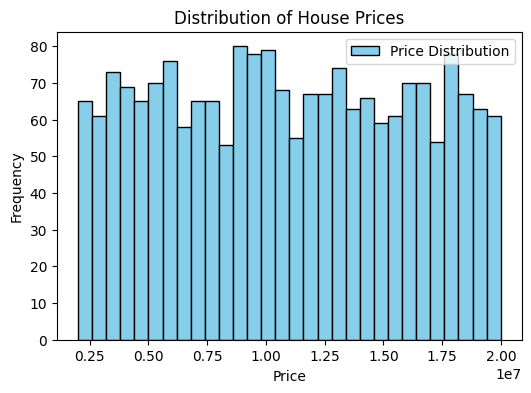

In [12]:
# Price Histogram
plt.figure(figsize=(6,4))
plt.hist(df["Price"],bins=30,color="skyblue",edgecolor="black",label="Price Distribution")
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.legend()
plt.show()

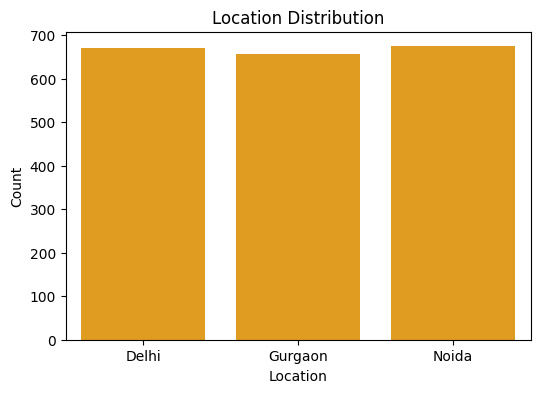

In [13]:
# Location Countplot
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Location", color="orange")
plt.title("Location Distribution")
plt.xlabel("Location")
plt.ylabel("Count")
plt.savefig("Location_Countplot.png", dpi=300, bbox_inches='tight')
plt.show()

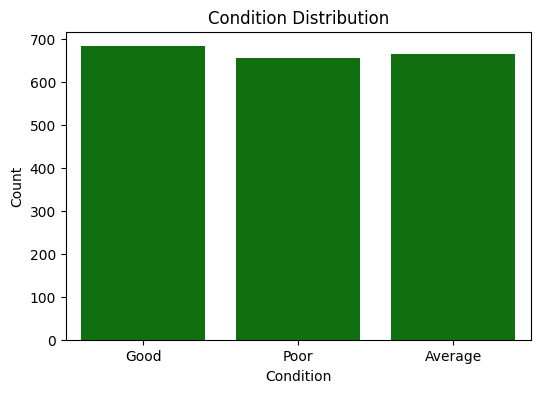

In [14]:
# Condition Countplot
plt.figure(figsize=(6,4))
sns.countplot(data=df,x="Condition",color="green")
plt.title("Condition Distribution")
plt.xlabel("Condition")
plt.ylabel("Count")
plt.savefig("Condition_Countplot.png",dpi=300,bbox_inches='tight')
plt.show()

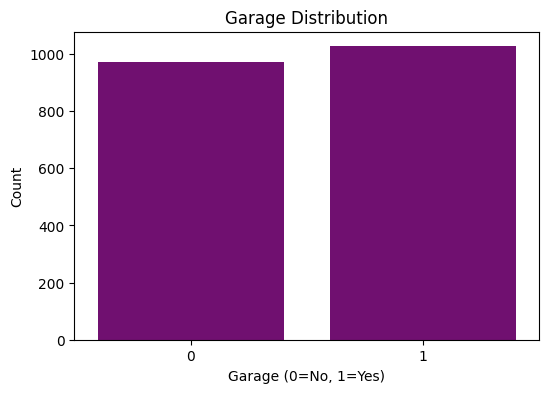

In [15]:
# Garage Countplot
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Garage", color="purple")
plt.title("Garage Distribution")
plt.xlabel("Garage (0=No, 1=Yes)")
plt.ylabel("Count")
plt.savefig("Garage_Countplot.png", dpi=300, bbox_inches='tight')
plt.show()

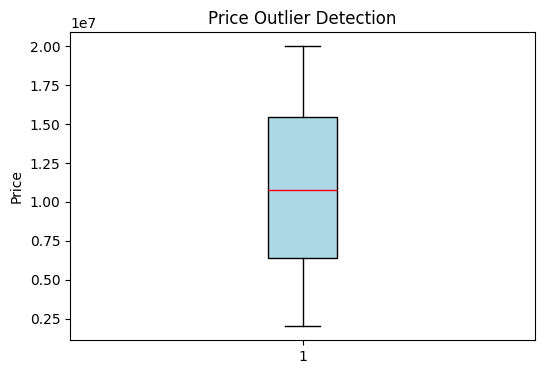

In [16]:
# Price Outlier Boxplot
plt.figure(figsize=(6,4))
plt.boxplot(df["Price"], patch_artist=True, boxprops=dict(facecolor='lightblue'),medianprops=dict(color='red'))
plt.title("Price Outlier Detection")
plt.ylabel("Price")
plt.savefig("Price_Boxplot.png", dpi=300, bbox_inches='tight')
plt.show()

#### 4. Bivariate Analysis

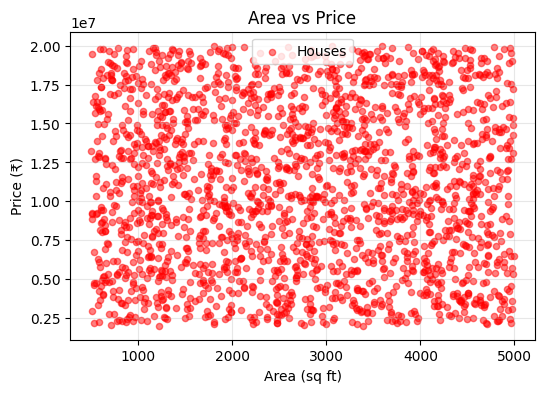

In [17]:
# Area vs Price (Scatter Plot)
plt.figure(figsize=(6,4))
plt.scatter(df["Area"], df["Price"], color="red", alpha=0.5, s=20, label="Houses")
plt.title("Area vs Price", fontsize=12)
plt.xlabel("Area (sq ft)", fontsize=10)
plt.ylabel("Price (₹)", fontsize=10)
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("Area_vs_Price.png", dpi=300, bbox_inches='tight')
plt.show()

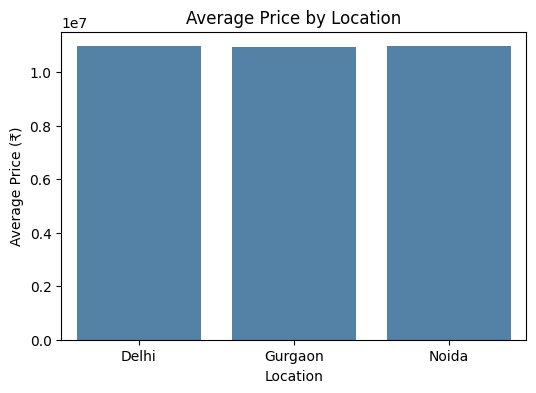

In [19]:
# Location VS Price (Bar plot)
plt.figure(figsize=(6,4))
sns.barplot(data=df,x="Location",y="Price",color="steelblue",errorbar=None)
plt.title("Average Price by Location",fontsize=12)
plt.xlabel("Location",fontsize=10)
plt.ylabel("Average Price (₹)",fontsize=10)
plt.savefig("Location_vs_price.png",dpi=300,bbox_inches="tight")
plt.show()

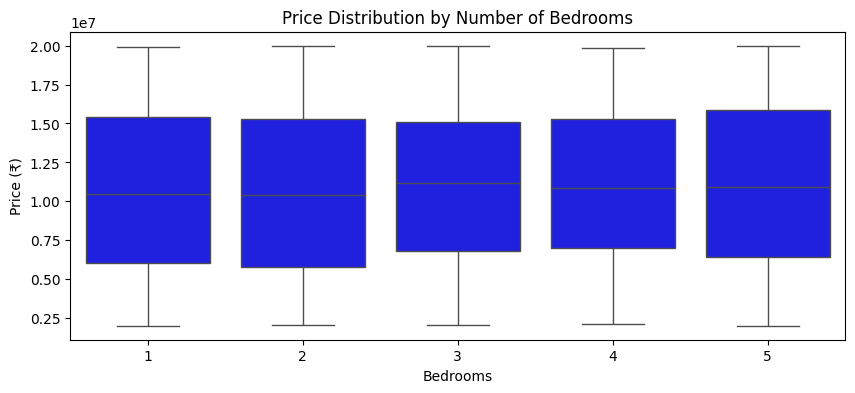

In [20]:
# Bedrooms vs Price (Boxplot)
plt.figure(figsize=(10,4))
sns.boxplot(data=df, x="Bedrooms", y="Price",color="Blue")
plt.title("Price Distribution by Number of Bedrooms",fontsize=12)
plt.xlabel("Bedrooms",fontsize=10)
plt.ylabel("Price (₹)",fontsize=10)
plt.savefig("Bedrooms_vs_Price.png", dpi=300, bbox_inches='tight')
plt.show()

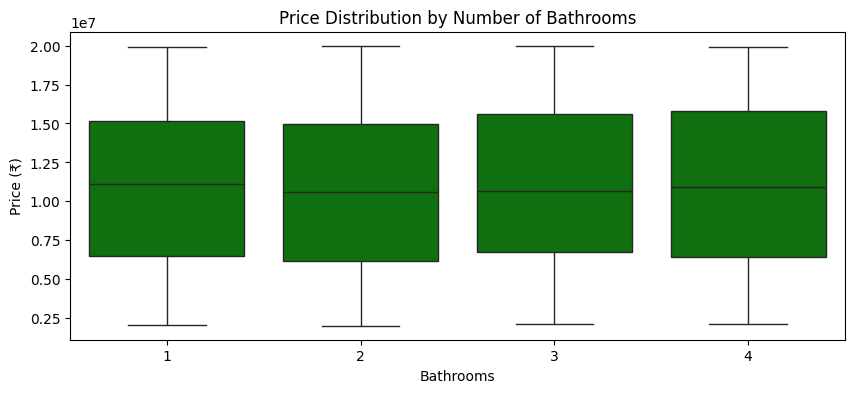

In [21]:
# Bathrooms vs Price (Boxplot)
plt.figure(figsize=(10,4))
sns.boxplot(data=df, x="Bathrooms", y="Price", color="Green")
plt.title("Price Distribution by Number of Bathrooms", fontsize=12)
plt.xlabel("Bathrooms", fontsize=10)
plt.ylabel("Price (₹)", fontsize=10)
plt.savefig("Bathrooms_vs_Price.png", dpi=300, bbox_inches='tight')
plt.show()

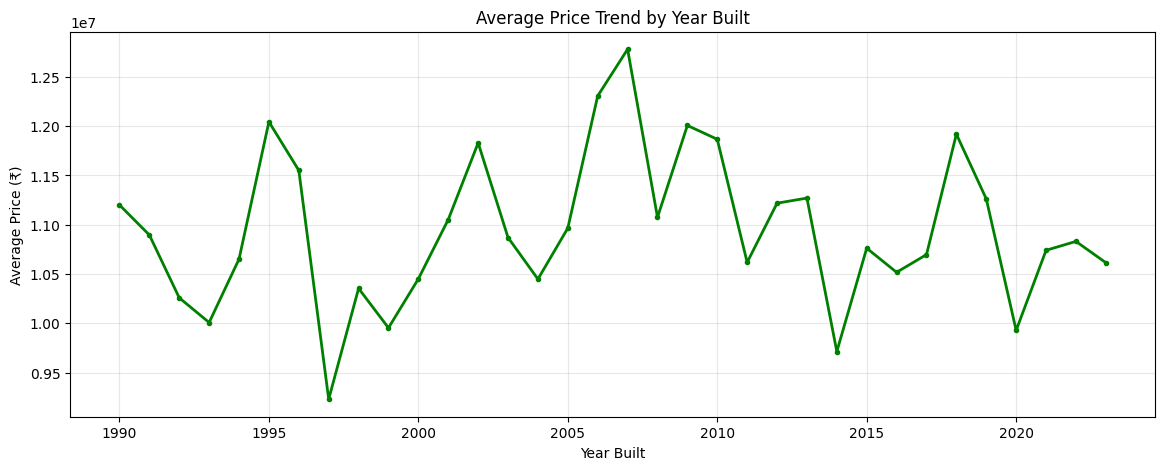

In [22]:
# YearBuilt Trend (Line Plot)
year_price = df.groupby("YearBuilt")["Price"].mean()
plt.figure(figsize=(14,5))
plt.plot(year_price.index, year_price.values, color="green", linewidth=2, marker='o', markersize=3)
plt.title("Average Price Trend by Year Built", fontsize=12)
plt.xlabel("Year Built", fontsize=10)
plt.ylabel("Average Price (₹)", fontsize=10)
plt.grid(True, alpha=0.3)
plt.savefig("YearBuilt_Trend.png", dpi=300, bbox_inches='tight')
plt.show()


#### 5. Feature Engineering

In [23]:
current_year=2025
df["Age"]=current_year-df["YearBuilt"]
df["Price_per_Sqft"]=df["Price"]/df["Area"]
df["Total_Rooms"]=df["Bedrooms"]+df["Bathrooms"]

print("\nNew Features Created:")
print(df[["Age","Price_per_Sqft","Total_Rooms"]].head())
print(f"\nAge range:{df['Age'].min()}to{df['Age'].max()} years")
print(f"Price per Sqft range:₹{df['Price_per_Sqft'].min():.0f} to ₹{df['Price_per_Sqft'].max():.0f}")
print(f"Total Rooms range:{df['Total_Rooms'].min()} + to{df['Total_Rooms'].max()}")


New Features Created:
   Age  Price_per_Sqft  Total_Rooms
0    5      552.409470            3
1   24     7600.013761            9
2   33    14479.463622            7
3   33     3780.135463            8
4    3     6564.665842            6

Age range:2to35 years
Price per Sqft range:₹433 to ₹38447
Total Rooms range:2 + to9


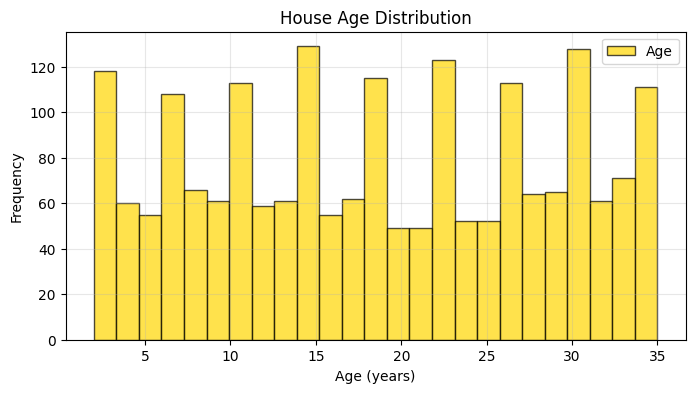

In [24]:
# Age Distribution (Histogram)
plt.figure(figsize=(8,4))
plt.hist(df["Age"], bins=25, color="gold", edgecolor="black", alpha=0.7, label="Age")
plt.title("House Age Distribution", fontsize=12)
plt.xlabel("Age (years)", fontsize=10)
plt.ylabel("Frequency", fontsize=10)
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("Age_Histogram.png", dpi=300, bbox_inches='tight')
plt.show()

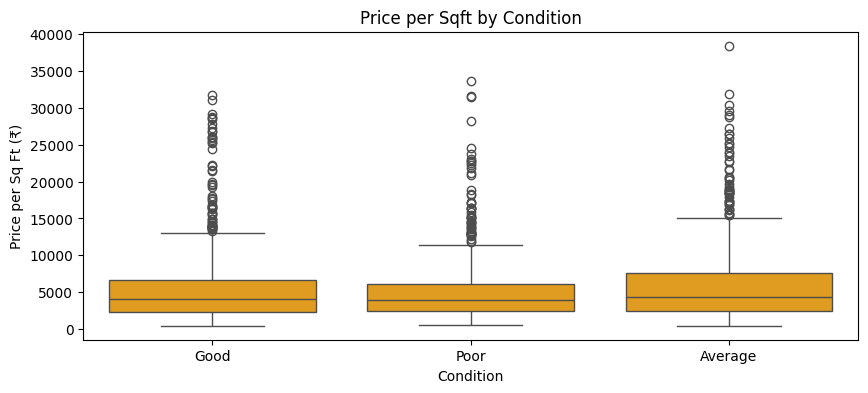

In [25]:
# Price per Sqft Boxplot by Condition
plt.figure(figsize=(10,4))
sns.boxplot(data=df, x="Condition", y="Price_per_Sqft", color="Orange")
plt.title("Price per Sqft by Condition", fontsize=12)
plt.xlabel("Condition", fontsize=10)
plt.ylabel("Price per Sq Ft (₹)", fontsize=10)
plt.savefig("PricePerSqft_Boxplot.png", dpi=300, bbox_inches='tight')
plt.show()

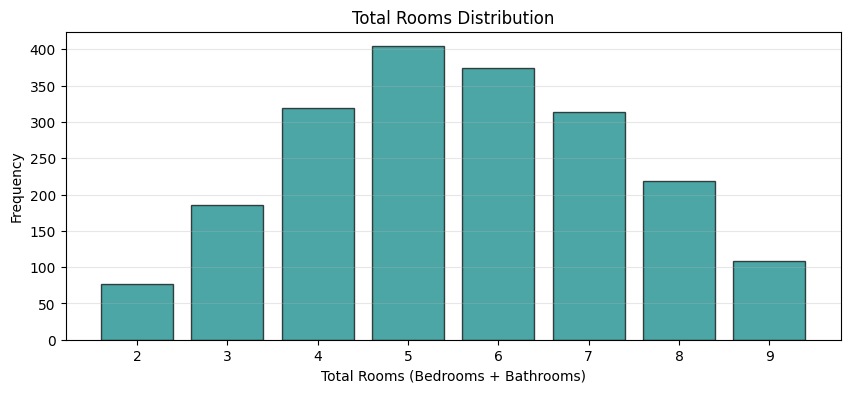

In [26]:
# Total Rooms Bar Chart
room_counts = df["Total_Rooms"].value_counts().sort_index()
plt.figure(figsize=(10,4))
plt.bar(room_counts.index, room_counts.values, color="teal", edgecolor='black', alpha=0.7)
plt.title("Total Rooms Distribution", fontsize=12)
plt.xlabel("Total Rooms (Bedrooms + Bathrooms)", fontsize=10)
plt.ylabel("Frequency", fontsize=10)
plt.grid(True, alpha=0.3, axis='y')
plt.savefig("TotalRooms_Bar.png", dpi=300, bbox_inches='tight')
plt.show()

#### 6. Multivariate Analysis

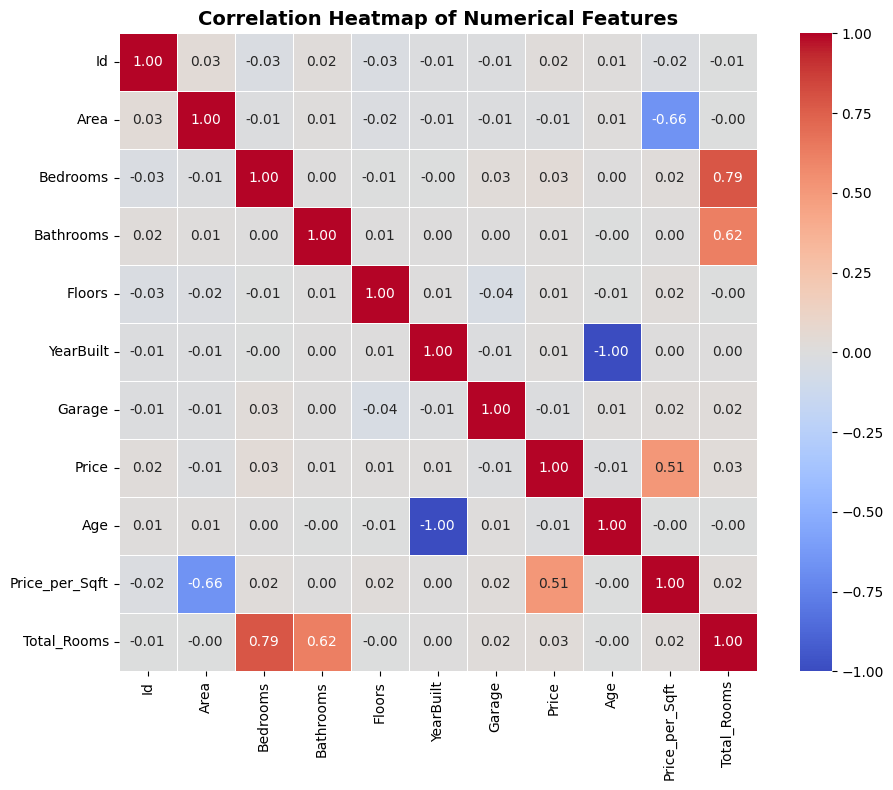

In [27]:
# Correlation Heatmap
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(),annot=True,cmap="coolwarm",fmt=".2f",linewidths=0.5, square=True)
plt.title("Correlation Heatmap of Numerical Features", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("Correlation_Heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

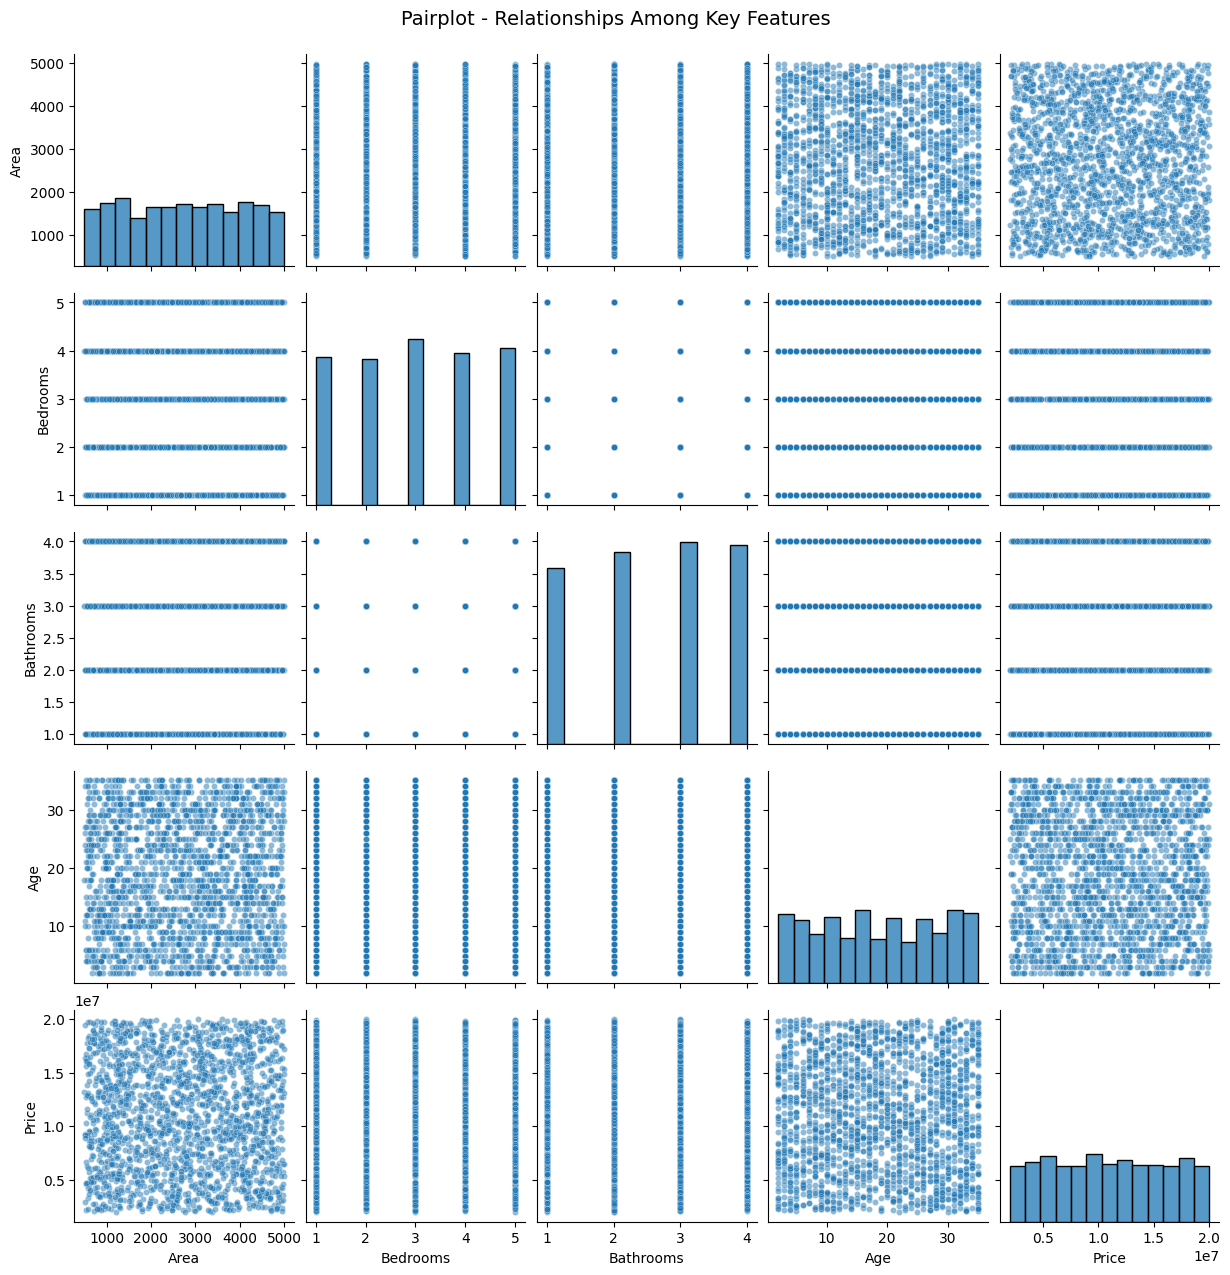

In [28]:
# Pairplot
pair_columns = ["Area", "Bedrooms", "Bathrooms", "Age", "Price"]
sns.pairplot(df[pair_columns], diag_kind='hist', plot_kws={'alpha':0.5, 's':20})
plt.suptitle("Pairplot - Relationships Among Key Features", y=1.02, fontsize=14)
plt.savefig("Pairplot.png", dpi=300, bbox_inches='tight')
plt.show()

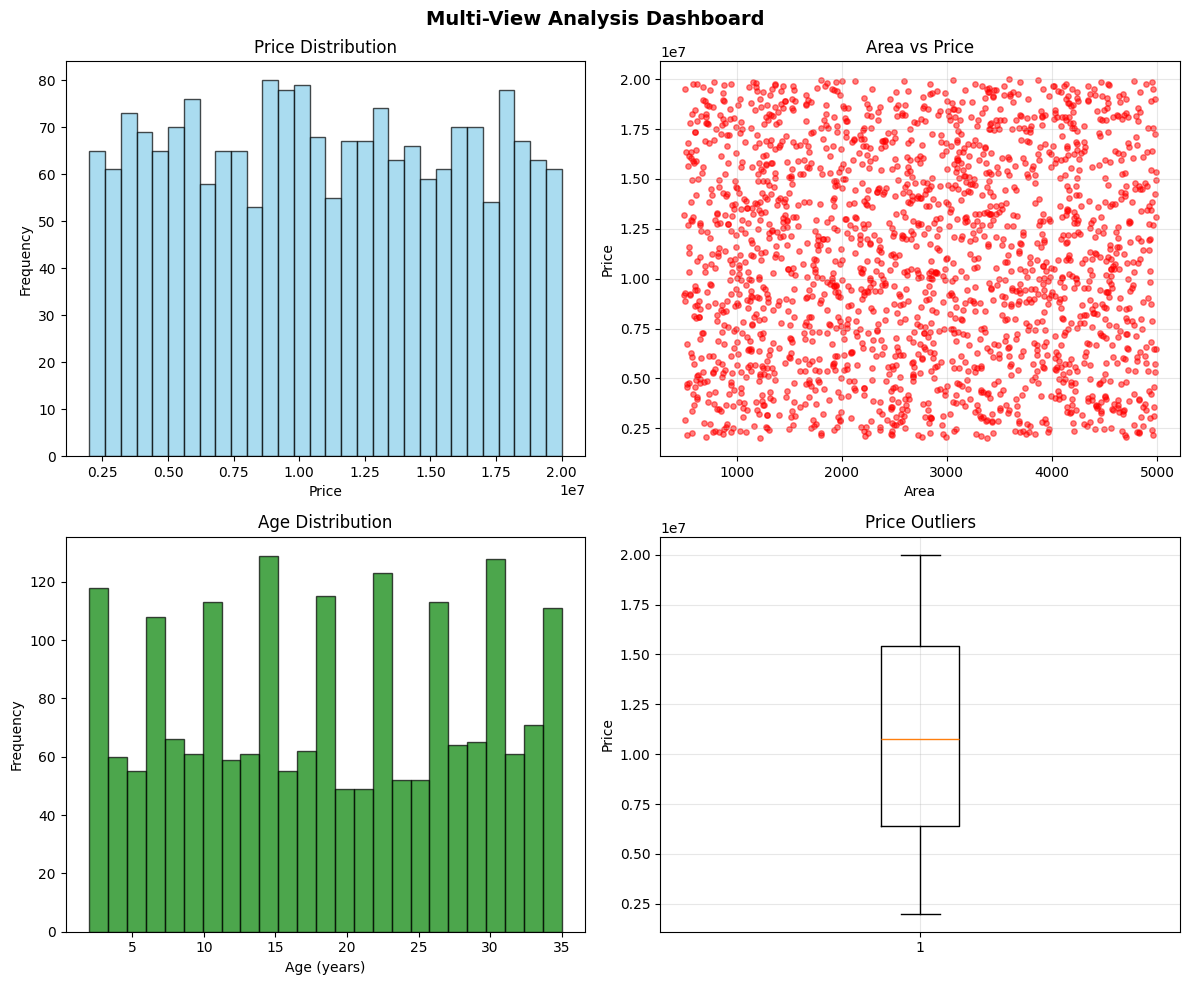

In [29]:
# Multi Chart Figure (2x2)
fig,axes=plt.subplots(2,2,figsize=(12,10))
fig.suptitle("Multi-View Analysis Dashboard", fontsize=14, fontweight='bold')

# Price Distribution (Histogram Chart)

axes[0,0].hist(df["Price"], bins=30, color="skyblue", edgecolor='black', alpha=0.7)
axes[0,0].set_title("Price Distribution")
axes[0,0].set_xlabel("Price")
axes[0,0].set_ylabel("Frequency")

# Aera VS Price (Scatter Plot)

axes[0,1].scatter(df["Area"], df["Price"], color="red", alpha=0.5, s=15)
axes[0,1].set_title("Area vs Price")
axes[0,1].set_xlabel("Area")
axes[0,1].set_ylabel("Price")
axes[0,1].grid(True, alpha=0.3)

# Age Distribution (Histogram plot)

axes[1,0].hist(df["Age"], bins=25, color="green", edgecolor='black', alpha=0.7)
axes[1,0].set_title("Age Distribution")
axes[1,0].set_xlabel("Age (years)")
axes[1,0].set_ylabel("Frequency")

#  Price Outliers (Boxplot) 

axes[1,1].boxplot(df["Price"])
axes[1,1].set_title("Price Outliers")
axes[1,1].set_ylabel("Price")
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("MultiChart_Figure.png", dpi=300, bbox_inches='tight')
plt.show()

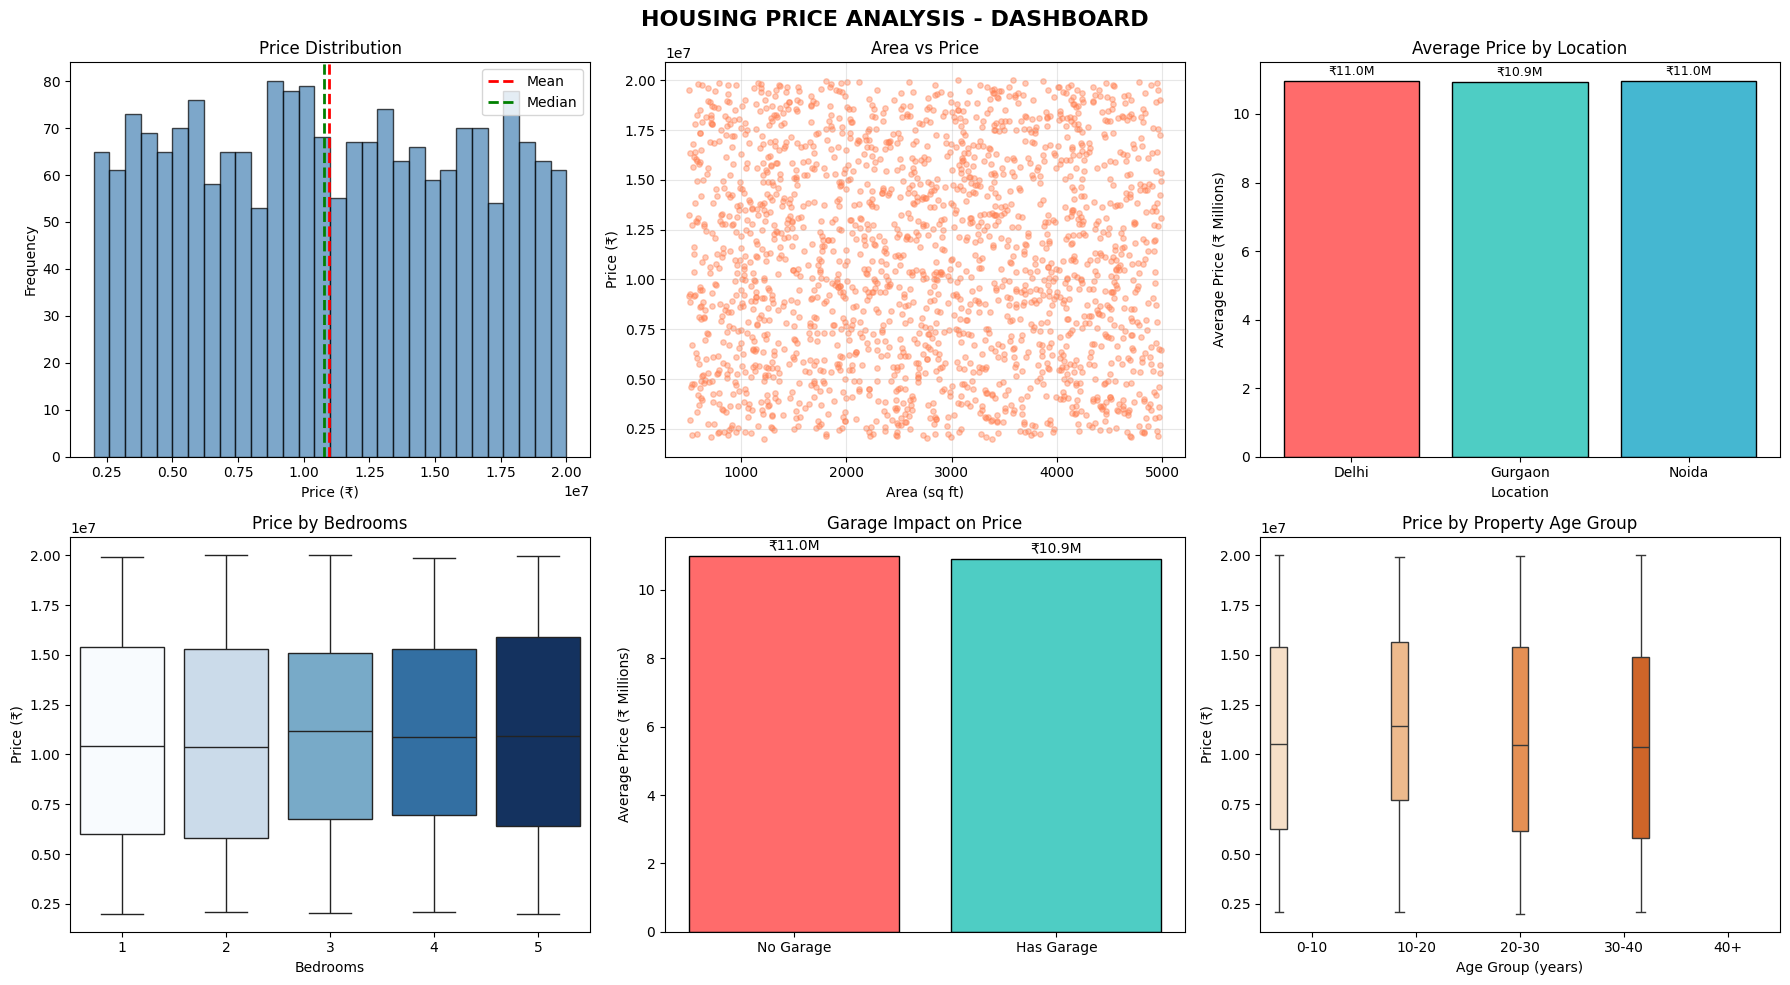

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("HOUSING PRICE ANALYSIS - DASHBOARD", fontsize=16, fontweight='bold')

# Chart 1: Price Distribution

axes[0,0].hist(df["Price"], bins=30, color="steelblue", edgecolor='black', alpha=0.7)
axes[0,0].axvline(df["Price"].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean')
axes[0,0].axvline(df["Price"].median(), color='green', linestyle='--', linewidth=2, label=f'Median')
axes[0,0].set_title("Price Distribution")
axes[0,0].set_xlabel("Price (₹)")
axes[0,0].set_ylabel("Frequency")
axes[0,0].legend()

# Chart 2: Area vs Price

axes[0,1].scatter(df["Area"], df["Price"], color="coral", alpha=0.4, s=15)
axes[0,1].set_title("Area vs Price")
axes[0,1].set_xlabel("Area (sq ft)")
axes[0,1].set_ylabel("Price (₹)")
axes[0,1].grid(True, alpha=0.3)

# Chart 3: Location vs Price

location_mean = df.groupby("Location")["Price"].mean()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = axes[0,2].bar(location_mean.index, location_mean.values/1e6, color=colors, edgecolor='black')
axes[0,2].set_title("Average Price by Location")
axes[0,2].set_xlabel("Location")
axes[0,2].set_ylabel("Average Price (₹ Millions)")
for bar, val in zip(bars, location_mean.values/1e6):
    axes[0,2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'₹{val:.1f}M', ha='center', va='bottom', fontsize=9)

# Chart 4: Bedrooms vs Price

sns.boxplot(data=df, x="Bedrooms", y="Price", ax=axes[1,0], hue="Bedrooms", palette="Blues", legend=False)
axes[1,0].set_title("Price by Bedrooms")
axes[1,0].set_xlabel("Bedrooms")
axes[1,0].set_ylabel("Price (₹)")

# Chart 5: Garage Impact

garage_price = df.groupby("Garage")["Price"].mean() / 1e6
bars = axes[1,1].bar(['No Garage', 'Has Garage'], garage_price.values,color=['#FF6B6B', '#4ECDC4'], edgecolor='black')
axes[1,1].set_title("Garage Impact on Price")
axes[1,1].set_ylabel("Average Price (₹ Millions)")
for bar, val in zip(bars, garage_price.values):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'₹{val:.1f}M', ha='center', va='bottom', fontsize=10)

# Chart 6: Age vs Price (Boxplot by Age Group)

df_temp = df.copy()
df_temp["Age_Group"] = pd.cut(df_temp["Age"], bins=[0,10,20,30,40,100], labels=['0-10', '10-20', '20-30', '30-40', '40+'])
sns.boxplot(data=df_temp, x="Age_Group", y="Price", ax=axes[1,2], hue="Age_Group", palette="Oranges", legend=False)
axes[1,2].set_title("Price by Property Age Group")
axes[1,2].set_xlabel("Age Group (years)")
axes[1,2].set_ylabel("Price (₹)")

plt.tight_layout()
plt.savefig("17_Final_Dashboard.png", dpi=300, bbox_inches='tight')
plt.show()

In [33]:
print("="*80)
print("✅ EDA PROJECT COMPLETED! ALL VISUALIZATIONS AND INSIGHTS GENERATED!")
print("="*80)

✅ EDA PROJECT COMPLETED! ALL VISUALIZATIONS AND INSIGHTS GENERATED!
